# MNIST PCA Phase Dataset

This notebook documents the input representation used by the MNIST optical benchmarks.

Learning goals:

1. Load the cached MNIST PCA phase features.
2. Understand the 16-dimensional phase-only representation.
3. Inspect feature ranges and encoded phases before training optical models.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print(f"Project root: {ROOT}")

RNG_SEED = 7

try:
    import numpy as np
    np.random.seed(RNG_SEED)
except ImportError:
    pass

print(f"Deterministic seed: {RNG_SEED}")


Project root: /Volumes/Storage/Github/Lumix
Deterministic seed: 7


## Build or Load the Notebook-Owned PCA Feature Cache

This notebook is self-contained. It downloads MNIST with `urllib`, computes PCA with NumPy, and writes a notebook-owned cache under `notebooks/repeated_encoding_tutorials/cache/`. It does not import any experiment script.


In [2]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = ROOT / "notebooks" / "repeated_encoding_tutorials"
CACHE_DIR = NOTEBOOK_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATASET_CACHE = CACHE_DIR / f"mnist_pca16_phase_no_clip_rng{RNG_SEED}.npz"
RAW_MNIST_CACHE = CACHE_DIR / "mnist_raw.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
WIDTH = 16
NUM_CLASSES = 10

def one_hot(labels, classes=NUM_CLASSES):
    return np.eye(classes, dtype=np.float32)[labels]

def download_mnist():
    if RAW_MNIST_CACHE.exists():
        return
    print(f"Downloading MNIST to {RAW_MNIST_CACHE.relative_to(ROOT)}")
    urllib.request.urlretrieve(MNIST_URL, RAW_MNIST_CACHE)

def fit_pca_phase_features_no_clip(train_images, test_images, width=WIDTH):
    train_flat = train_images.reshape(train_images.shape[0], -1).astype(np.float32) / 255.0
    test_flat = test_images.reshape(test_images.shape[0], -1).astype(np.float32) / 255.0

    pixel_mean = train_flat.mean(axis=0, keepdims=True)
    train_centered = train_flat - pixel_mean
    test_centered = test_flat - pixel_mean

    covariance = (train_centered.T @ train_centered) / train_centered.shape[0]
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    components = eigenvectors[:, np.argsort(eigenvalues)[::-1][:width]].astype(np.float32)

    train_scores = train_centered @ components
    test_scores = test_centered @ components
    score_mean = train_scores.mean(axis=0, keepdims=True)
    score_std = train_scores.std(axis=0, keepdims=True)
    score_std = np.where(score_std == 0.0, 1.0, score_std)

    train_standardized = (train_scores - score_mean) / score_std
    test_standardized = (test_scores - score_mean) / score_std
    train_min = train_standardized.min(axis=0, keepdims=True)
    train_max = train_standardized.max(axis=0, keepdims=True)
    train_range = np.where(train_max == train_min, 1.0, train_max - train_min)

    x_train = ((train_standardized - train_min) / train_range).astype(np.float32)
    x_test = ((test_standardized - train_min) / train_range).astype(np.float32)
    return x_train, x_test, eigenvalues[np.argsort(eigenvalues)[::-1][:width]].astype(np.float32)

if DATASET_CACHE.exists():
    cached = np.load(DATASET_CACHE)
    x_train, y_train = cached["x_train"], cached["y_train"]
    x_test, y_test = cached["x_test"], cached["y_test"]
    explained_variance = cached["explained_variance"]
    print(f"Loaded notebook-owned dataset cache: {DATASET_CACHE.relative_to(ROOT)}")
else:
    download_mnist()
    raw = np.load(RAW_MNIST_CACHE)
    x_train, x_test, explained_variance = fit_pca_phase_features_no_clip(raw["x_train"], raw["x_test"])
    y_train = one_hot(raw["y_train"])
    y_test = one_hot(raw["y_test"])
    np.savez_compressed(
        DATASET_CACHE,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        explained_variance=explained_variance,
        rng_seed=np.asarray(RNG_SEED),
        source="notebook:02_mnist_pca_phase_dataset:self_contained",
    )
    print(f"Wrote notebook-owned dataset cache: {DATASET_CACHE.relative_to(ROOT)}")

print("x_train:", x_train.shape, x_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_test:", x_test.shape)
print("feature min/max:", float(x_train.min()), float(x_train.max()))


Wrote notebook-owned dataset cache: notebooks/repeated_encoding_tutorials/cache/mnist_pca16_phase_no_clip_rng7.npz
x_train: (60000, 16) float32
y_train: (60000, 10) float32
x_test: (10000, 16)
feature min/max: 0.0 1.0


The optical model receives `x` as a real vector of length 16. It does not use amplitude encoding. The optical field starts as a uniform complex field, and the data changes the field through the phase mask.


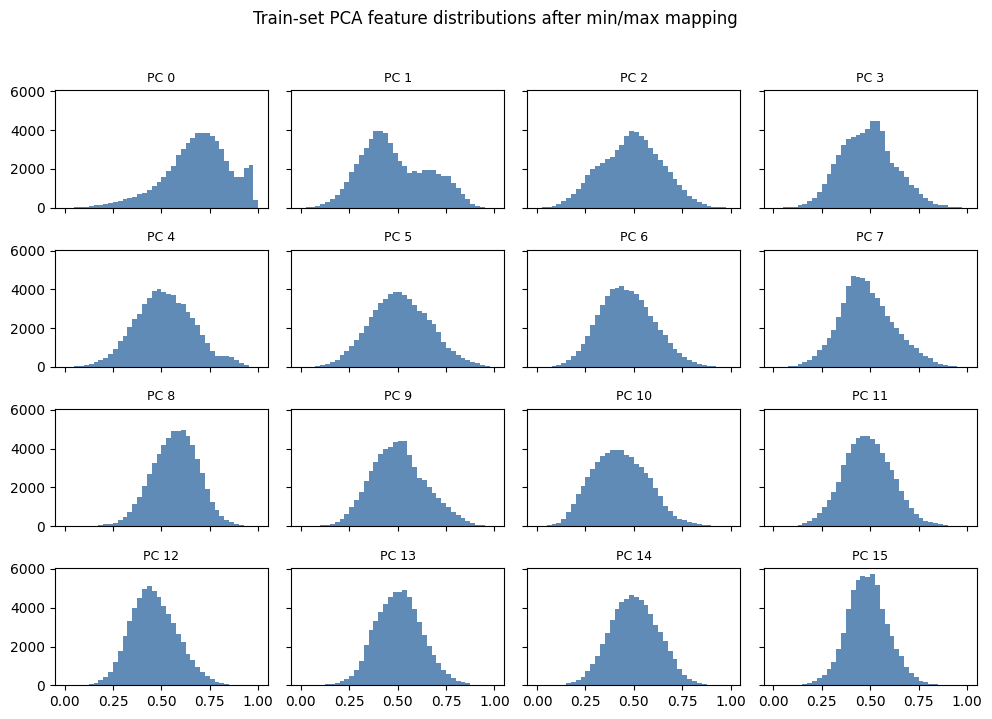

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(10, 7), sharex=True, sharey=True)
for idx, ax in enumerate(axes.flat):
    ax.hist(x_train[:, idx], bins=40, color="#4477aa", alpha=0.85)
    ax.set_title(f"PC {idx}", fontsize=9)
plt.suptitle("Train-set PCA feature distributions after min/max mapping", y=1.02)
plt.tight_layout()
plt.show()


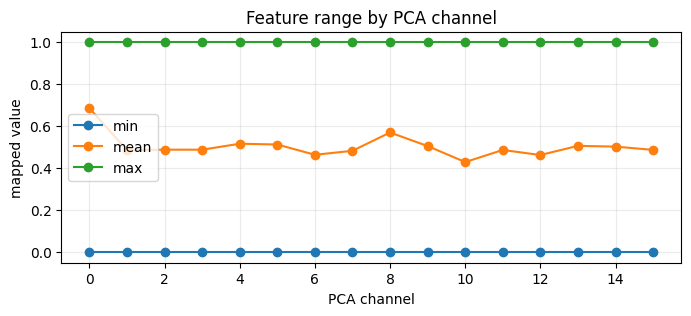

In [4]:
feature_min = x_train.min(axis=0)
feature_max = x_train.max(axis=0)
feature_mean = x_train.mean(axis=0)

plt.figure(figsize=(8, 3))
plt.plot(feature_min, marker="o", label="min")
plt.plot(feature_mean, marker="o", label="mean")
plt.plot(feature_max, marker="o", label="max")
plt.title("Feature range by PCA channel")
plt.xlabel("PCA channel")
plt.ylabel("mapped value")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Phase Encoding

The benchmark uses `alpha = pi`, so the nominal phase is

```text
phi_j = pi * x_j
```

For train features mapped into `[0, 1]`, this gives a nominal phase range of `0` to `pi`.


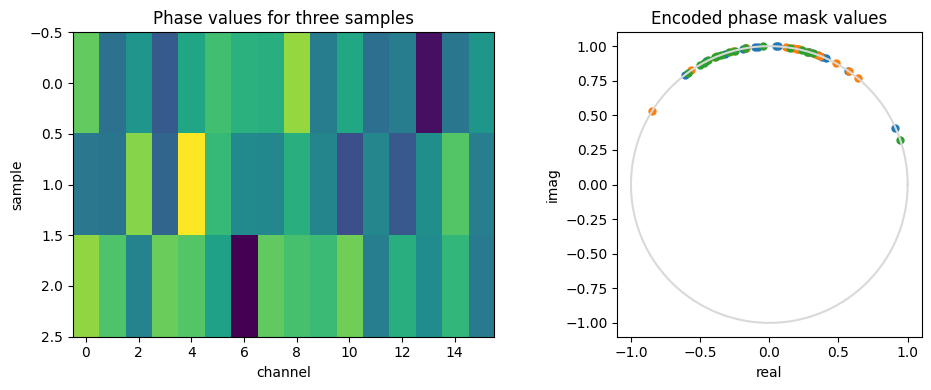

In [5]:
alpha = np.pi
sample_indices = [0, 1, 2]
phases = alpha * x_train[sample_indices]
mask = np.exp(1j * phases)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(phases, aspect="auto", cmap="viridis")
axes[0].set_title("Phase values for three samples")
axes[0].set_xlabel("channel")
axes[0].set_ylabel("sample")

circle = np.linspace(0, 2 * np.pi, 256)
axes[1].plot(np.cos(circle), np.sin(circle), color="0.85")
for row in mask:
    axes[1].scatter(row.real, row.imag, s=25)
axes[1].set_aspect("equal")
axes[1].set_title("Encoded phase mask values")
axes[1].set_xlabel("real")
axes[1].set_ylabel("imag")
plt.tight_layout()
plt.show()


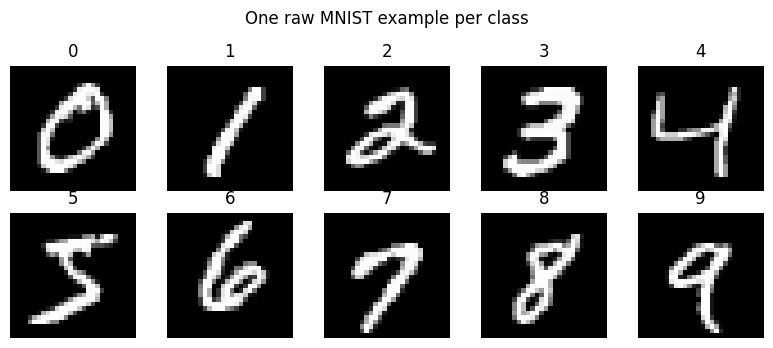

In [6]:
raw_path = RAW_MNIST_CACHE
if raw_path.exists():
    raw = np.load(raw_path)
    labels = raw["y_train"]
    images = raw["x_train"]
    fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
    for digit, ax in enumerate(axes.flat):
        idx = int(np.flatnonzero(labels == digit)[0])
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(str(digit))
        ax.axis("off")
    plt.suptitle("One raw MNIST example per class")
    plt.tight_layout()
    plt.show()
else:
    print("Raw MNIST cache not found; run the dataset cell first.")


## Exercise

Pick one PCA channel and compare its histogram before and after multiplying by `pi`. The shape should not change; only the units change from normalized feature value to radians.
